# 🎮 Dự Án Game Churn Prediction & Player Analytics
## Notebook 03: Modeling and Explain 

> **Mục tiêu chính:**
> 1. Đảm bảo mô hình chỉ được học từ những thông tin mà thực tế hệ thống thu thập được trước khi người chơi bỏ game.
> 2. Giúp ta có cái nhìn đa chiều, không bị "đánh lừa" bởi một chỉ số Accuracy đơn lẻ.
> 3. Để chứng minh rằng giải pháp XGBoost/Random Forest được chọn có thực sự vượt trội hơn một thuật toán thống kê đơn giản hay không .
> 4. Dự đoán ai bỏ game mới xong 50%, 50% còn lại là biết lý do (ví dụ: ít vào game, cày mãi không lên level) để gửi đúng voucher/quà tặng giữ chân họ.
> 5. Đưa sản phẩm ra khỏi Jupyter Notebook để tái sử dụng trên Web API (FastAPI) và Dashboard (Streamlit).



In [11]:
# 1. Khai báo các thư viện cần thiết
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


---
## 1. Load dữ liệu đã tiền xử lý và xác minh danh sách đặc trưng đầu vào:
Đọc dữ liệu train và test được tải về từ thư mục `data/processed/test_features.csv` và `data/processed/train_features.csv`.


In [12]:
import pandas as pd
train_df = pd.read_csv('../data/processed/train_features.csv')
test_df = pd.read_csv('../data/processed/test_features.csv')
X_train, y_train = train_df.drop(columns=['IsChurn']), train_df['IsChurn']
X_test, y_test = test_df.drop(columns=['IsChurn']), test_df['IsChurn']


---
## 2. Implement hàm đánh giá toàn diện các chỉ số phân loại nhị phân:
Viết sẵn hàm tính đồng thời: Accuracy, Precision, Recall, F1, ROC-AUC.


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

def evaluate_classifier(model, X, y, model_name="Model"):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else y_pred
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred),
        "F1-Score": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_proba),
        "PR-AUC": average_precision_score(y, y_proba)
    }


---
## 3. Implement và so sánh đồng thời 3 thuật toán (Logistic Regression, Random Forest, XGBoost):
- **Logistic Regression**: Mô hình tuyến tính chuẩn mực (Baseline).
- **Random Forest**: Kết hợp biểu quyết từ nhiều cây độc lập.
- **XGBoost**: Cây sau sửa lỗi cho cây trước, thường đạt quán quân trong thực tế.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42)
}
results = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    results.append(evaluate_classifier(clf, X_test, y_test, model_name=name))
pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.840515,0.634932,0.897821,0.743831,0.925782,0.849763
1,Random Forest,0.938554,0.867695,0.898789,0.882969,0.939156,0.882808
2,XGBoost,0.954540,0.929763,0.891041,0.909990,0.938555,0.889475


---
## 4. Add phân tích độ quan trọng của đặc trưng (SHAP Values) cho mô hình tốt nhất:   
Bóc tách "hộp đen" của AI: Chỉ ra **tại sao** người chơi A bị xếp vào nhóm nguy cơ bỏ game

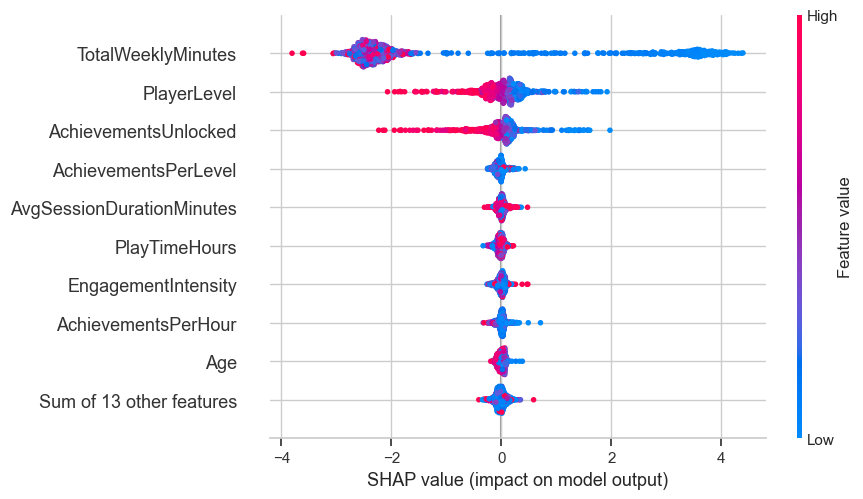

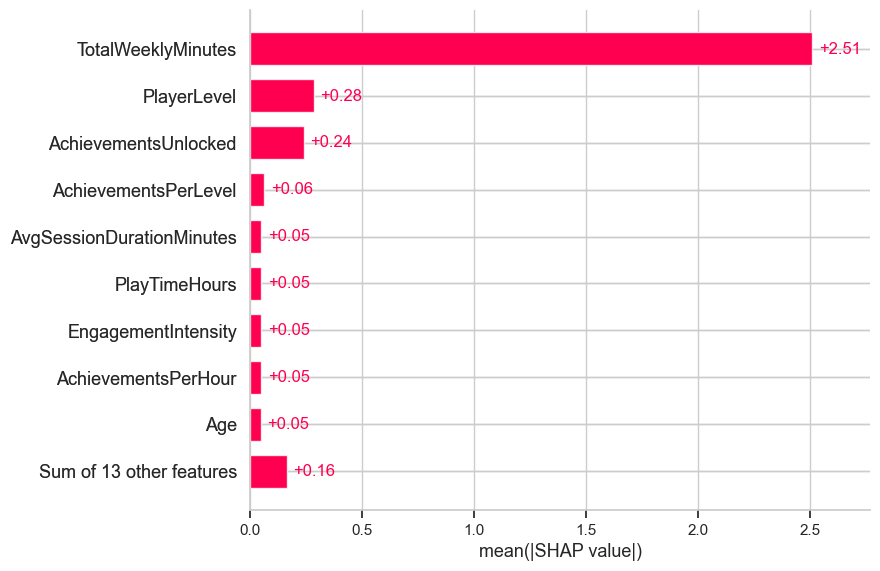

In [17]:
import shap
best_clf = models["XGBoost"]
explainer = shap.TreeExplainer(best_clf)
shap_values = explainer(X_test.iloc[:1000])
shap.plots.beeswarm(shap_values, max_display=10)
plt.figure(figsize=(10, 5))
shap.plots.bar(shap_values, max_display=10)


---
## Task 5: Run lưu trữ model artifact và danh sách feature chuẩn hóa ra thư mục models/:
Đưa sản phẩm ra khỏi Jupyter Notebook để tái sử dụng trên Web API (FastAPI) và Dashboard (Streamlit).

In [16]:
import joblib
from pathlib import Path
Path('../models').mkdir(parents=True, exist_ok=True)
joblib.dump(best_clf, '../models/best_model.joblib')
joblib.dump(list(X_train.columns), '../models/model_features.joblib')
print("Model và feature names đã được lưu thành công vào thư mục models/!")


Model và feature names đã được lưu thành công vào thư mục models/!


---
## **Mục tiêu**: Xây dựng và hoàn thiện pipeline huấn luyện mô hình dự đoán rời bỏ game (03_Modeling.ipynb).
**Thay đổi chính**:

- Thử nghiệm và so sánh Logistic Regression, Random Forest và XGBoost Classifier.
- Xử lý mất cân bằng dữ liệu thông qua scale_pos_weight và tối ưu F1/ROC-AUC.
- Tích hợp phân tích SHAP bóc tách top đặc trưng thúc đẩy người chơi Churn.
- Xuất artifact models/best_model.joblib và model_features.joblib.
- **How to review**: Mở notebooks/03_Modeling.ipynb, chạy từ cell đầu đến cuối, kiểm tra bảng so sánh metrics và file được xuất trong models/.
- **Tests run**: Đã thực thi pytest tests/test_modeling.py xác minh hợp đồng dữ liệu và kiểm tra rò rỉ đặc trưng.